#Graph Construction & PyTorch Geometric Pipeline

## Overview
This notebook executes and validates the end-to-end graph construction pipeline implemented in `src/Fraudsentinel/graph_construction.py`. It converts raw Bitcoin transaction features, classes, and edgelist files into a single, standardized, and fully validated PyTorch Geometric `Data` object (`data/processed/graph_data.pt`).

In [9]:
import sys
from pathlib import Path
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sys.path.append(str(Path("../src").resolve()))
from Fraudsentinel.graph_construction import (
    load_raw_data,
    remap_nodes,
    engineer_topological_features,
    create_pyg_data,
    build_and_save_graph
)

sns.set_theme(style="whitegrid", palette="muted")

##  Execute End-to-End Pipeline
Running `build_and_save_graph()` which:
1. Loads raw CSVs from `data/raw/archive/elliptic_bitcoin_dataset/`.
2. Remaps transaction IDs to `0..N-1` sequential node indices.
3. Engineers 5 topological features (`in_degree`, `out_degree`, `total_degree`, `pagerank`, `community_id`).
4. Assembles node feature matrix `x`, edge index `edge_index`, labels `y`, time steps `time_step`, and temporal split boolean masks.
5. Saves the final graph object to `data/processed/graph_data.pt`.

In [10]:
raw_dir = Path("../data/raw/archive/elliptic_bitcoin_dataset")
processed_file = Path("../data/processed/graph_data.pt")

graph_data = build_and_save_graph(data_dir=raw_dir, output_path=processed_file)

[ 2026-08-08 17:19:47,119 ] 35 FraudSentinel.GraphConstruction - INFO - Loading raw dataset from ..\data\raw\archive\elliptic_bitcoin_dataset...
[ 2026-08-08 17:19:54,723 ] 43 FraudSentinel.GraphConstruction - INFO - Raw data loaded: 203769 features rows, 203769 classes rows, 234355 edges rows.
[ 2026-08-08 17:19:54,725 ] 63 FraudSentinel.GraphConstruction - INFO - Remapping transaction IDs to 0..N-1 sequential node indices...


F:\Intern\projects\FraudSentinel\src\Fraudsentinel\graph_construction.py:68: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features_df["node_idx"] = features_df["txId"].map(id_to_idx)


[ 2026-08-08 17:19:55,471 ] 86 FraudSentinel.GraphConstruction - INFO - Remapping complete. 203769 nodes, 234355 valid edges.
[ 2026-08-08 17:19:55,475 ] 102 FraudSentinel.GraphConstruction - INFO - Engineering topological features for 203769 nodes...
[ 2026-08-08 17:19:57,094 ] 115 FraudSentinel.GraphConstruction - INFO - Computing PageRank centrality...
[ 2026-08-08 17:19:58,047 ] 119 FraudSentinel.GraphConstruction - INFO - Performing Community Detection...
[ 2026-08-08 17:21:14,877 ] 140 FraudSentinel.GraphConstruction - INFO - Topological features computed successfully.
[ 2026-08-08 17:21:14,893 ] 153 FraudSentinel.GraphConstruction - INFO - Assembling PyTorch Geometric Data object...
[ 2026-08-08 17:21:15,157 ] 192 FraudSentinel.GraphConstruction - INFO - PyG Data assembled: nodes=203769, edges=234355, features=170
[ 2026-08-08 17:21:15,159 ] 196 FraudSentinel.GraphConstruction - INFO - Mask breakdown: Train=29894, Val=9983, Test=6687, Unknown/Unlabeled=157205
[ 2026-08-08 17:21:

##  Graph Data Object Verification
We verify that the saved `Data` object satisfies all integrity and dimension constraints.

In [11]:
print("=== PyTorch Geometric Data Summary ===")
print(f"Data Object: {graph_data}")
print(f"Number of Nodes: {graph_data.num_nodes:,}")
print(f"Number of Edges: {graph_data.num_edges:,}")
print(f"Number of Node Features: {graph_data.num_node_features}")
print(f"Feature Matrix Shape (x): {graph_data.x.shape}")
print(f"Edge Index Tensor Shape (edge_index): {graph_data.edge_index.shape}")
print(f"Label Tensor Shape (y): {graph_data.y.shape}")
print(f"Has Isolated Nodes: {graph_data.has_isolated_nodes()}")
print(f"Has Self Loops: {graph_data.has_self_loops()}")
print(f"Is Directed: {graph_data.is_directed()}")

=== PyTorch Geometric Data Summary ===
Data Object: Data(x=[203769, 170], edge_index=[2, 234355], y=[203769], train_mask=[203769], val_mask=[203769], test_mask=[203769], time_step=[203769], labeled_mask=[203769])
Number of Nodes: 203,769
Number of Edges: 234,355
Number of Node Features: 170
Feature Matrix Shape (x): torch.Size([203769, 170])
Edge Index Tensor Shape (edge_index): torch.Size([2, 234355])
Label Tensor Shape (y): torch.Size([203769])
Has Isolated Nodes: False
Has Self Loops: False
Is Directed: True


##  Temporal Split Mask Validation
We verify that the train/val/test masks partition the dataset chronologically and exclude `unknown` nodes from loss calculations.

In [12]:
train_count = graph_data.train_mask.sum().item()
val_count = graph_data.val_mask.sum().item()
test_count = graph_data.test_mask.sum().item()
unlabeled_count = (graph_data.y == -1).sum().item()
total_count = graph_data.num_nodes

print("=== Temporal Split & Mask Breakdown ===")
print(f"Train Mask (Time Steps 1-34, Labeled): {train_count:,} ({train_count/total_count:.2%})")
print(f"Val Mask   (Time Steps 35-42, Labeled): {val_count:,} ({val_count/total_count:.2%})")
print(f"Test Mask  (Time Steps 43-49, Labeled): {test_count:,} ({test_count/total_count:.2%})")
print(f"Unlabeled / Unknown Nodes (y == -1)   : {unlabeled_count:,} ({unlabeled_count/total_count:.2%})")
print(f"Total Nodes Verification              : {train_count + val_count + test_count + unlabeled_count:,} / {total_count:,}")

overlap = (graph_data.train_mask & graph_data.val_mask).sum() + \
          (graph_data.train_mask & graph_data.test_mask).sum() + \
          (graph_data.val_mask & graph_data.test_mask).sum()
print(f"Mask Overlap Count: {overlap.item()} (Must be 0)")
assert overlap.item() == 0, "Error: Overlap detected between split masks!"

=== Temporal Split & Mask Breakdown ===
Train Mask (Time Steps 1-34, Labeled): 29,894 (14.67%)
Val Mask   (Time Steps 35-42, Labeled): 9,983 (4.90%)
Test Mask  (Time Steps 43-49, Labeled): 6,687 (3.28%)
Unlabeled / Unknown Nodes (y == -1)   : 157,205 (77.15%)
Total Nodes Verification              : 203,769 / 203,769
Mask Overlap Count: 0 (Must be 0)


##  Class Distribution Across Temporal Splits
We check the number of illicit (1) and licit (0) transactions in train, val, and test splits.

In [13]:
def analyze_split_classes(name, mask, y_tensor):
    y_split = y_tensor[mask]
    illicit = (y_split == 1).sum().item()
    licit = (y_split == 0).sum().item()
    total = len(y_split)
    illicit_pct = (illicit / total * 100) if total > 0 else 0
    print(f"[{name}] Total Labeled: {total:,} | Illicit: {illicit:,} ({illicit_pct:.2f}%) | Licit: {licit:,}")

analyze_split_classes("TRAIN SPLIT", graph_data.train_mask, graph_data.y)
analyze_split_classes("VAL SPLIT  ", graph_data.val_mask, graph_data.y)
analyze_split_classes("TEST SPLIT ", graph_data.test_mask, graph_data.y)

[TRAIN SPLIT] Total Labeled: 29,894 | Illicit: 3,462 (11.58%) | Licit: 26,432
[VAL SPLIT  ] Total Labeled: 9,983 | Illicit: 914 (9.16%) | Licit: 9,069
[TEST SPLIT ] Total Labeled: 6,687 | Illicit: 169 (2.53%) | Licit: 6,518


##  Topological Feature Distributions
Visualizing engineered features (in-degree, out-degree, total degree, PageRank).

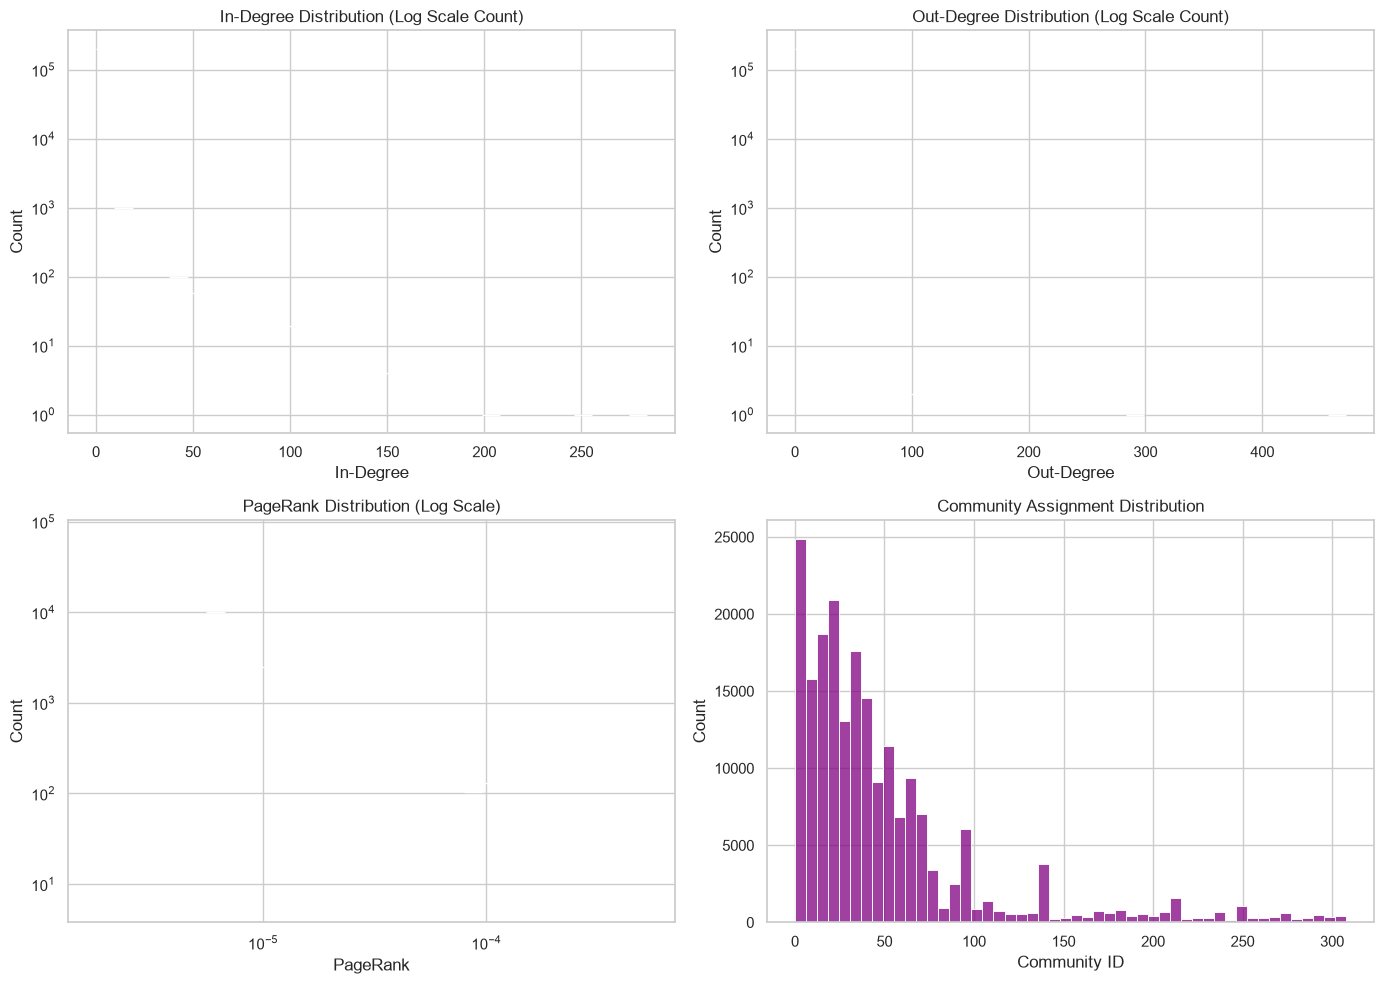

In [14]:
topo_array = graph_data.x[:, -5:].numpy()
topo_df_plot = pd.DataFrame(
    topo_array,
    columns=["In-Degree", "Out-Degree", "Total Degree", "PageRank", "Community ID"]
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(topo_df_plot["In-Degree"], bins=30, ax=axes[0, 0], log_scale=(False, True), color="skyblue")
axes[0, 0].set_title("In-Degree Distribution (Log Scale Count)")

sns.histplot(topo_df_plot["Out-Degree"], bins=30, ax=axes[0, 1], log_scale=(False, True), color="salmon")
axes[0, 1].set_title("Out-Degree Distribution (Log Scale Count)")

sns.histplot(topo_df_plot["PageRank"], bins=30, ax=axes[1, 0], log_scale=(True, True), color="teal")
axes[1, 0].set_title("PageRank Distribution (Log Scale)")


sns.histplot(topo_df_plot["Community ID"], bins=50, ax=axes[1, 1], color="purple")
axes[1, 1].set_title("Community Assignment Distribution")

plt.tight_layout()
plt.show()

##  Sanity Check on Sample Illicit Transaction
We inspect node `idx=0` or a known illicit transaction to confirm features, label, and connections match expected values.

In [15]:

illicit_indices = (graph_data.y == 1).nonzero(as_tuple=True)[0]
sample_idx = illicit_indices[0].item()

print(f"=== Sanity Check: Sample Illicit Node (Index: {sample_idx}) ===")
print(f"Label y[{sample_idx}]: {graph_data.y[sample_idx].item()} (1 = Illicit)")
print(f"Time Step: {graph_data.time_step[sample_idx].item()}")
print(f"Train Mask: {graph_data.train_mask[sample_idx].item()}")
print(f"Val Mask: {graph_data.val_mask[sample_idx].item()}")
print(f"Test Mask: {graph_data.test_mask[sample_idx].item()}")
print(f"Raw Features Snippet (first 5): {graph_data.x[sample_idx, :5].numpy()}")
print(f"Engineered Topological Features (last 5): {graph_data.x[sample_idx, -5:].numpy()}")


outgoing_neighbors = graph_data.edge_index[1, graph_data.edge_index[0] == sample_idx].tolist()
incoming_neighbors = graph_data.edge_index[0, graph_data.edge_index[1] == sample_idx].tolist()
print(f"Outgoing Neighbors Count: {len(outgoing_neighbors)}")
print(f"Incoming Neighbors Count: {len(incoming_neighbors)}")

=== Sanity Check: Sample Illicit Node (Index: 849) ===
Label y[849]: 1 (1 = Illicit)
Time Step: 42
Train Mask: False
Val Mask: True
Test Mask: False
Raw Features Snippet (first 5): [-0.17263192  0.46625808  1.5735946   0.17818043 -0.04387455]
Engineered Topological Features (last 5): [3.00000e+00 1.00000e+00 4.00000e+00 8.62499e-06 1.30000e+01]
Outgoing Neighbors Count: 1
Incoming Neighbors Count: 3
